<a href="https://colab.research.google.com/github/yujimin9161-oss/Hashing/blob/main/20251209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1

1)체이닝은 같은 해시 주소를 가지는 데이터들을 연결 리스트로 묶어서 관리하는 방법이다.

장점:연결 리스트를 사용하므로 메모리를 동적으로 할당받아 해시 테이블의 크기에 구애받지 않고 데이터를 계속 삽입할 수 있다. 해시 함수를 구현하거나 충돌을 해결하는 로직이 비교적 간단하다.

단점:포인터를 저장할 추가적인 메모리 공간이 필요하다.연결 리스트를 탐색해야 하므로 캐시 효율이 떨어져 탐색 속도가 느려질 수 있다.

2)개방 주소법은 충돌이 발생하면 비어있는 다른 해시 버킷을 찾아 데이터를 저장하는 방법이다.

장점:포인터 등 추가적인 메모리 공간을 사용하지 않고 해시 테이블 내의 공간만 사용하므로 메모리 효율이 좋다.연속된 배열 공간을 사용하므로 체이닝에 비해 캐시 효율이 좋다.

단점:데이터가 특정 영역에 몰리는 군집화 현상이 발생하면 탐색/삽입 성능이 급격히 저하된다.해시 테이블의 크기보다 많은 데이터를 저장할 수 없다.또 데이터 삭제 시 일반적인 비움 처리 대신 삭제 표시를 해야 탐색이 끊기지 않으므로 관리가 까다롭다.

##2-01

두 가지 큰 결점이 존재한다. 해시 함수 $h(x) = x \% 1024$의 결과값은 항상 0부터 1023 사이의 값만 나온다. 때문에 전체 테이블 크기를 1,204로 잡았음에도 불구하고, 인덱스 1024부터 1203까지의 공간(총 180개)은 어떤 키가 들어오더라도 절대 사용되지 않아 메모리가 낭비된다.
 $1024$는 $2^{10}$으로 2의 거듭제곱 수이다.
또 부적절한 해시 분포로 해시 함수를 2의 거듭제곱으로 나눈 나머지를 사용하면, 키 값의 하위 10개 비트만 해시 주소 결정에 사용되고 상위 비트들은 무시된다. 이는 키들이 특정 패턴을 가질 경우 해시 충돌을 빈번하게 발생시킬 위험이 있다.

##2-02

해시 함수가 갖추어야 할 가장 기본적이고 필수적인 조건은 결정론적이어야 한다는 것이다.즉, 동일한 입력(키 $x$)이 주어지면 항상 동일한 출력(해시 주소)을 반환해야 한다. 하지만 위 함수는 난수 생성 함수인 $\text{random}(0,10)$을 포함하고 있으므로, 같은 키 $x$를 입력하더라도 매번 다른 주소값이 계산된다.이렇게 되면 처음에 데이터를 삽입한 위치를 나중에 탐색하거나 삭제할 때 다시 찾아갈 수 없으므로 해시 함수로서 기능할 수 없다.

##2-04
해시 함수: $h(x) = x \% 13$
충돌 해결: $h_i(x) = (h(x) + i) \% 13$ (단, $i = 0, 1, 2, \dots$)
입력 키: 10, 20, 30, 40, 33, 46, 50, 60

10 삽입: $10 \% 13 = 10$ $\rightarrow$ 인덱스 10

20 삽입: $20 \% 13 = 7$ $\rightarrow$ 인덱스 7

30 삽입: $30 \% 13 = 4$ $\rightarrow$ 인덱스 4

40 삽입: $40 \% 13 = 1$ $\rightarrow$ 인덱스 1

33 삽입: $33 \% 13 = 7$ (충돌) $\rightarrow$ $i=1$: $(7+1) \% 13 = 8$ $\rightarrow$ 인덱스 8

46 삽입: $46 \% 13 = 7$ (충돌) $\rightarrow$ $i=1$: 8(충돌), $i=2$: $(7+2) \% 13 = 9$ $\rightarrow$ 인덱스 9

50 삽입: $50 \% 13 = 11$ $\rightarrow$ 인덱스 11

60 삽입: $60 \% 13 = 8$ (충돌) $\rightarrow$ $i=1$: 9(충돌), $i=2$: 10(충돌), $i=3$: 11(충돌), $i=4$: $(8+4) \% 13 = 12$ $\rightarrow$ 인덱스 12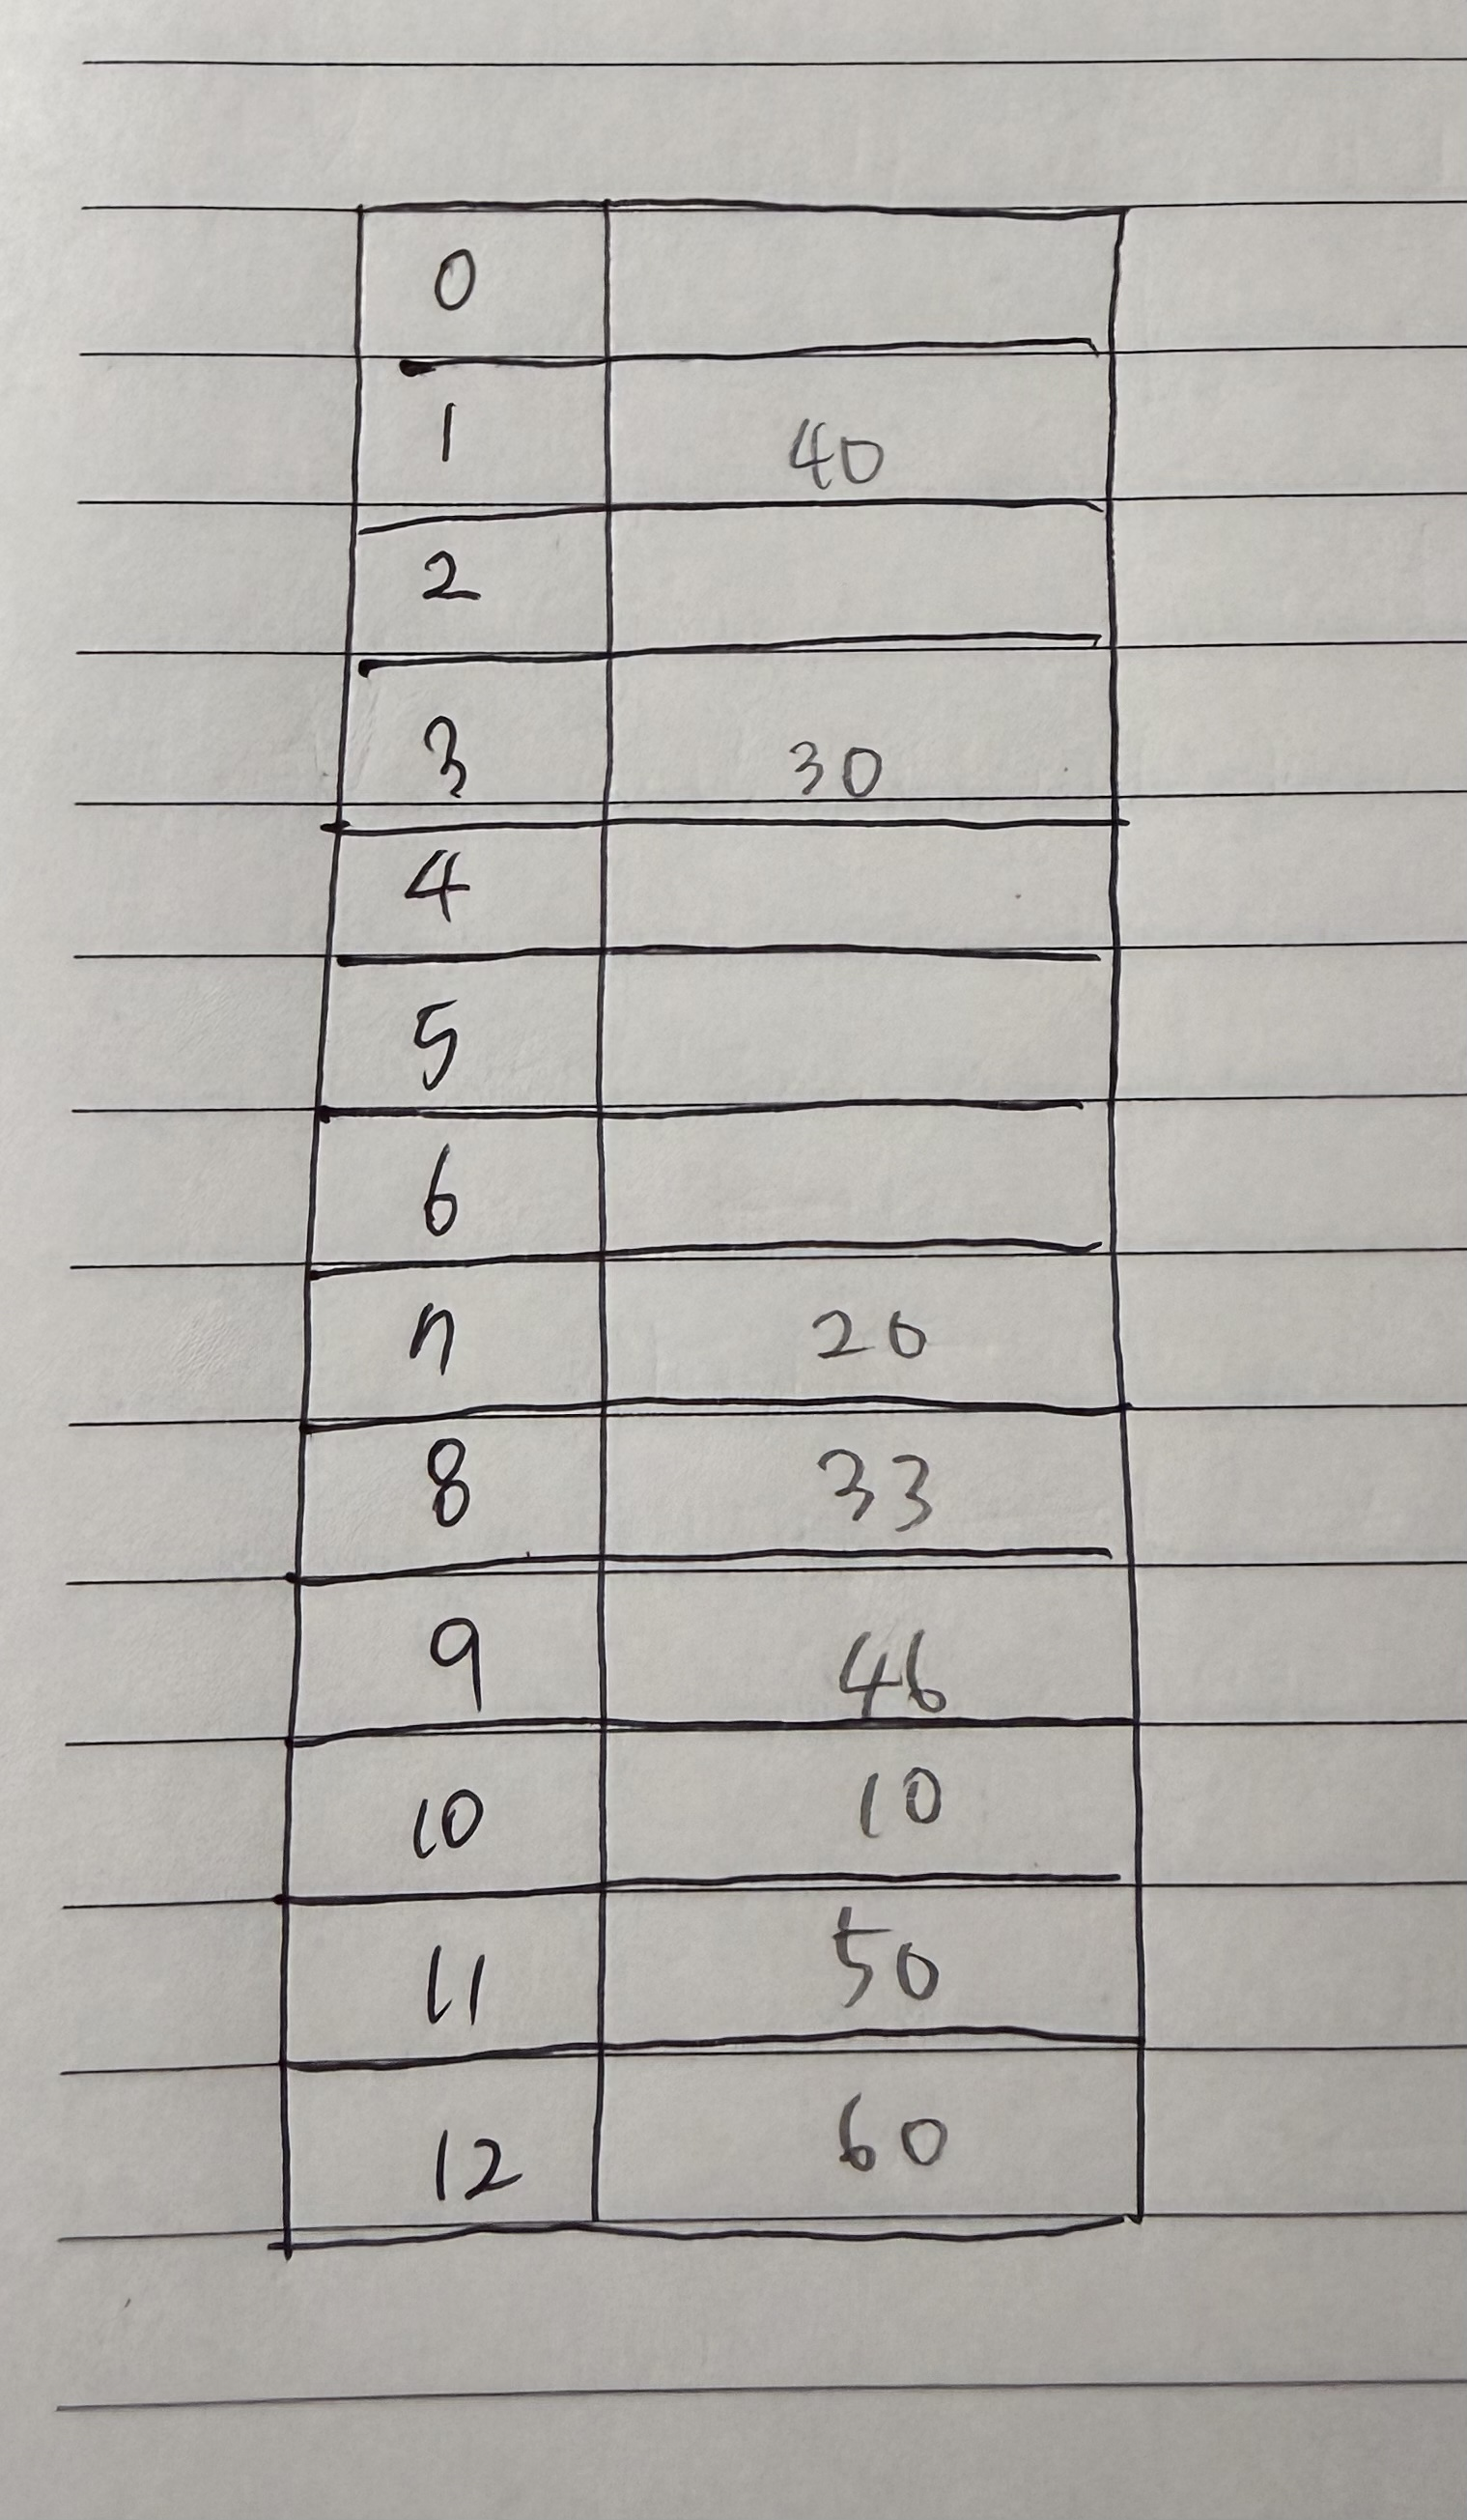

##2-05
충돌 해결: $h_i(x) = (h(x) + i^2) \% 13$

10(인덱스 10), 20(인덱스 7), 30(인덱스 4), 40(인덱스 1)까지는 위와 동일.

33 삽입: $h(33) = 7$ (충돌) $\rightarrow$ $i=1$: $(7 + 1^2) \% 13 = 8$ $\rightarrow$ 인덱스 8

46 삽입: $h(46) = 7$ (충돌) $\rightarrow$ $i=1$: $(7 + 1^2) \% 13 = 8$ (충돌) $\rightarrow$ $i=2$: $(7 + 2^2) \% 13 = 11$ $\rightarrow$ 인덱스 11

50 삽입: $h(50) = 11$ (충돌, 46이 있음) $\rightarrow$ $i=1$: $(11 + 1^2) \% 13 = 12$ $\rightarrow$ 인덱스 12

60 삽입: $h(60) = 8$ (충돌, 33이 있음) $\rightarrow$ $i=1$: $(8 + 1^2) \% 13 = 9$ $\rightarrow$ 인덱스 9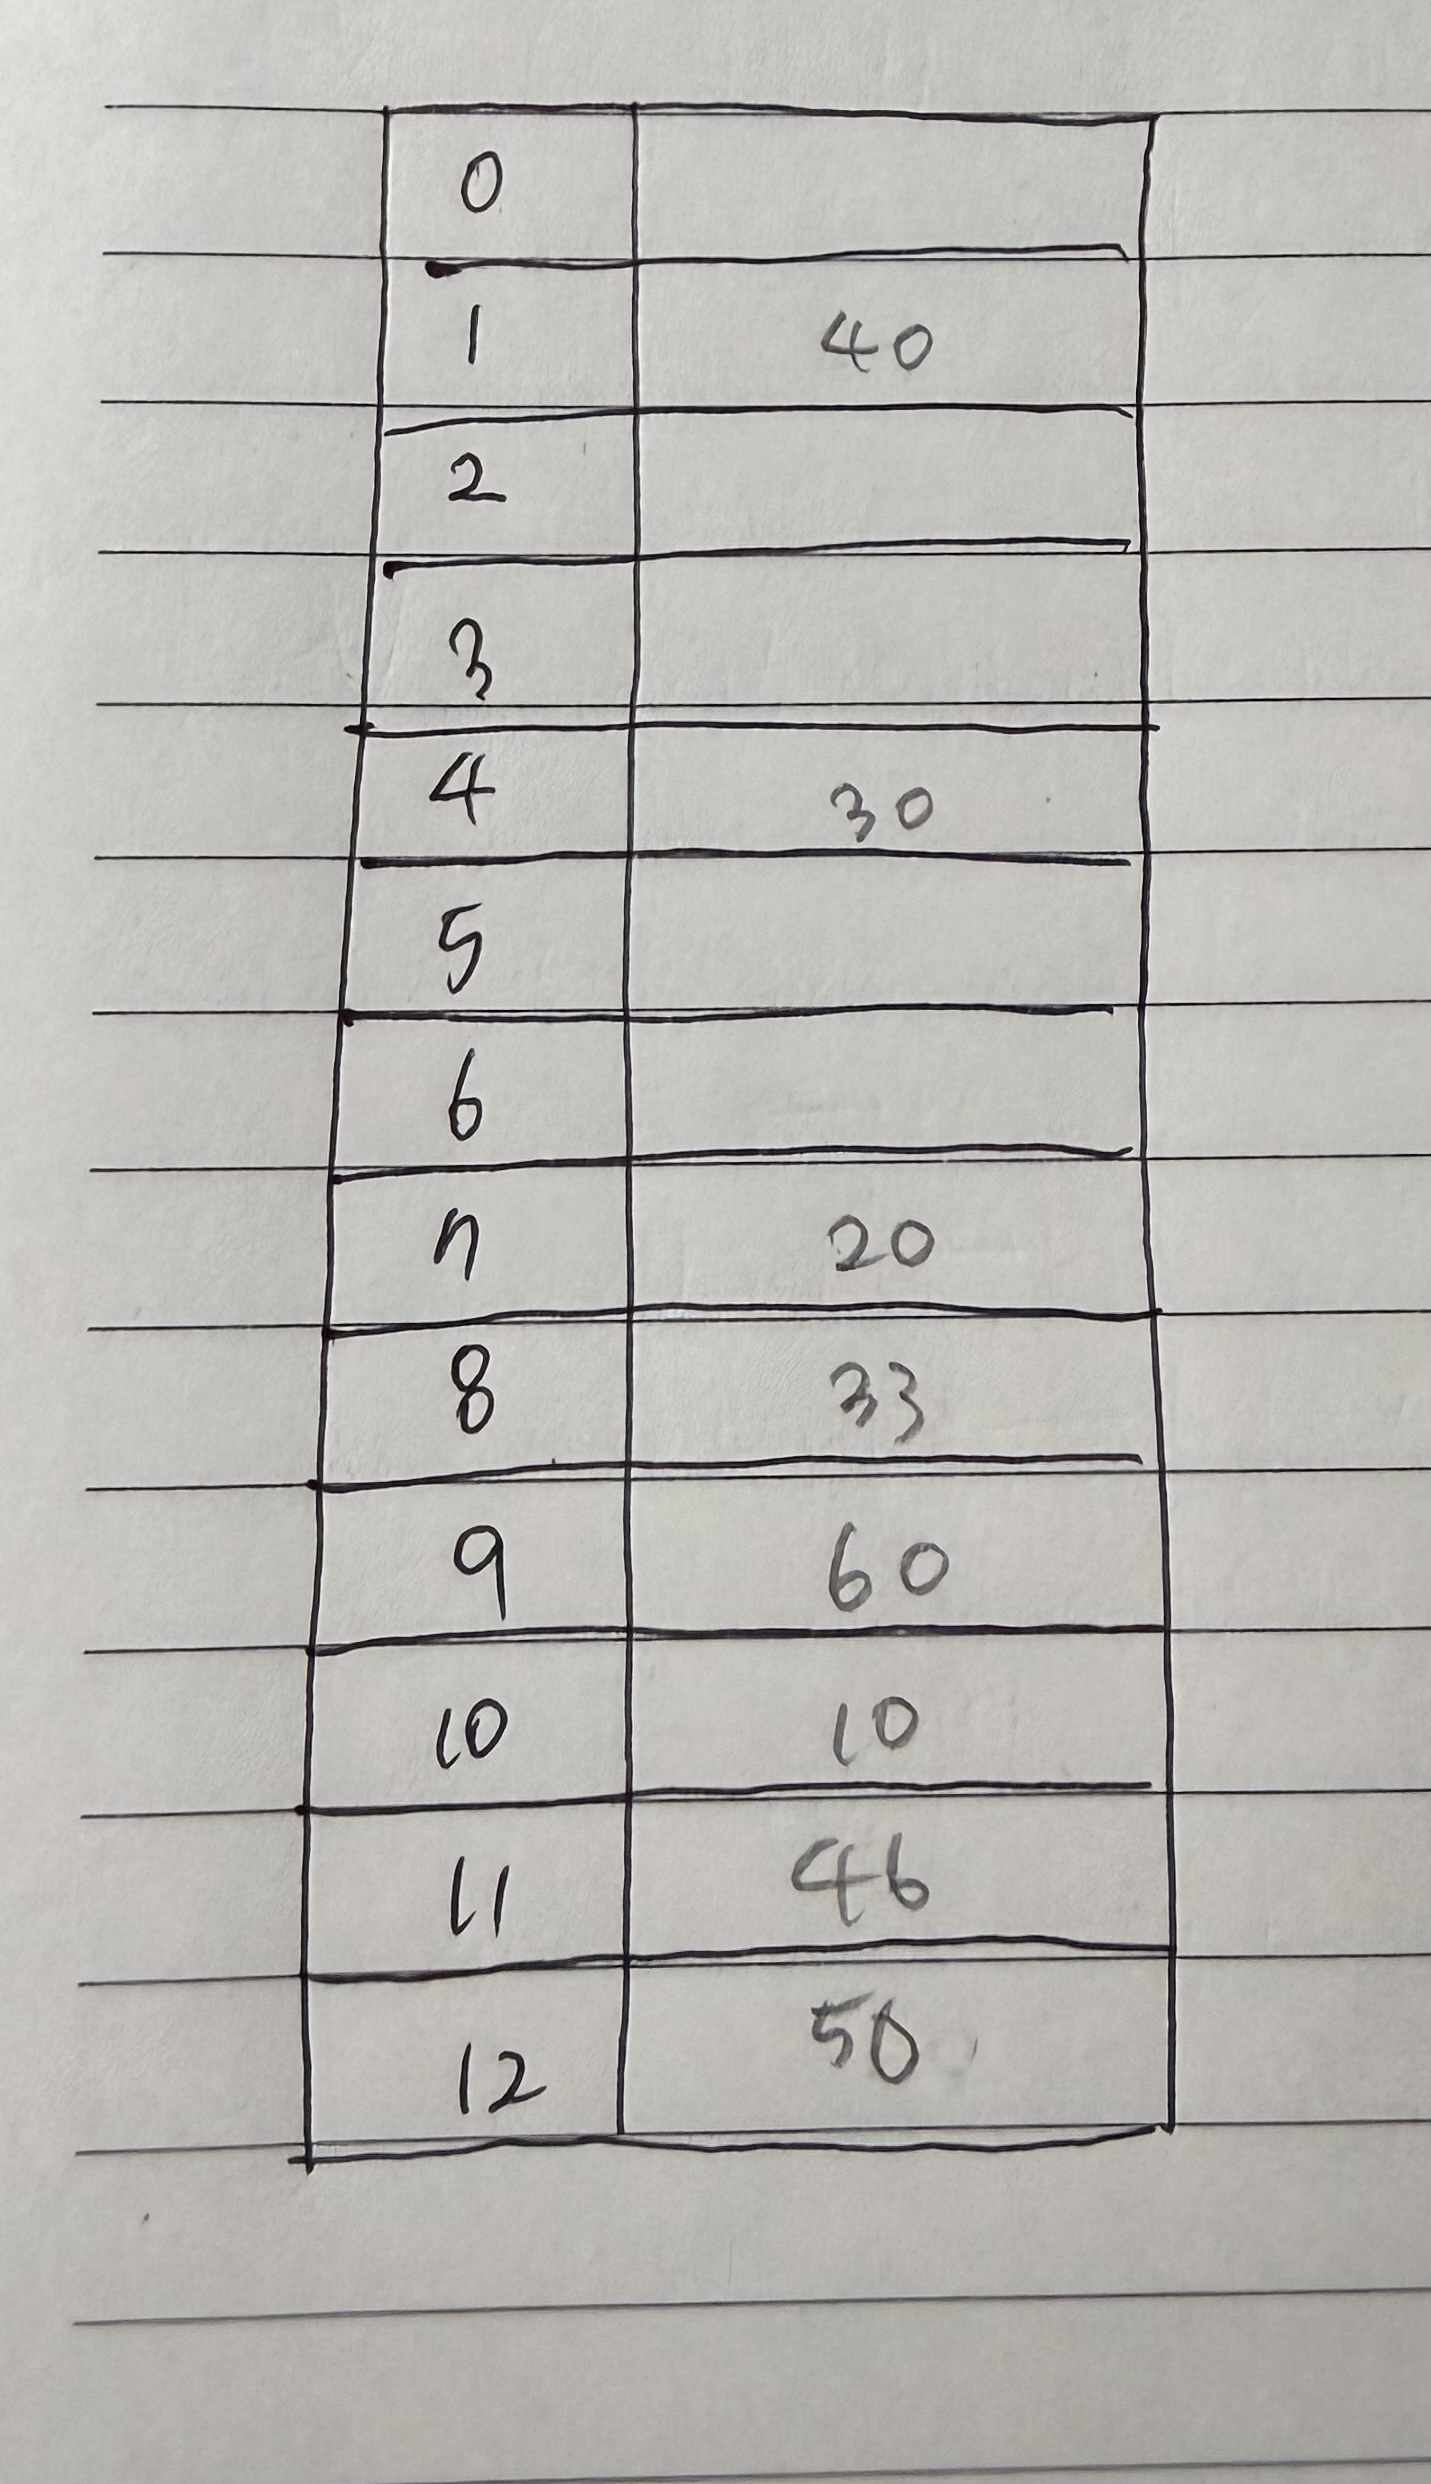

##2-06
탐색 방법: $h_i(x) = (h(x) + i \cdot f(x)) \pmod{13}$$h(x) = x \pmod{13}$$f(x) = 1 + (x \pmod{11})$

10, 20, 30, 40: 충돌 없으므로 동일 (10, 7, 4, 1 위치)

33: $h(33)=7$ (충돌). $f(33) = 1+(33\%11) = 1$.$(7 + 1 \cdot 1) \pmod{13} = 8$ → [8] 저장

46: $h(46)=7$ (충돌). $f(46) = 1+(46\%11) = 3$.$(7 + 1 \cdot 3) \pmod{13} = 10$ (충돌)$(7 + 2 \cdot 3) \pmod{13} = 0$ → [0] 저장

50: $h(50)=11$. 충돌 없음 → [11] 저장

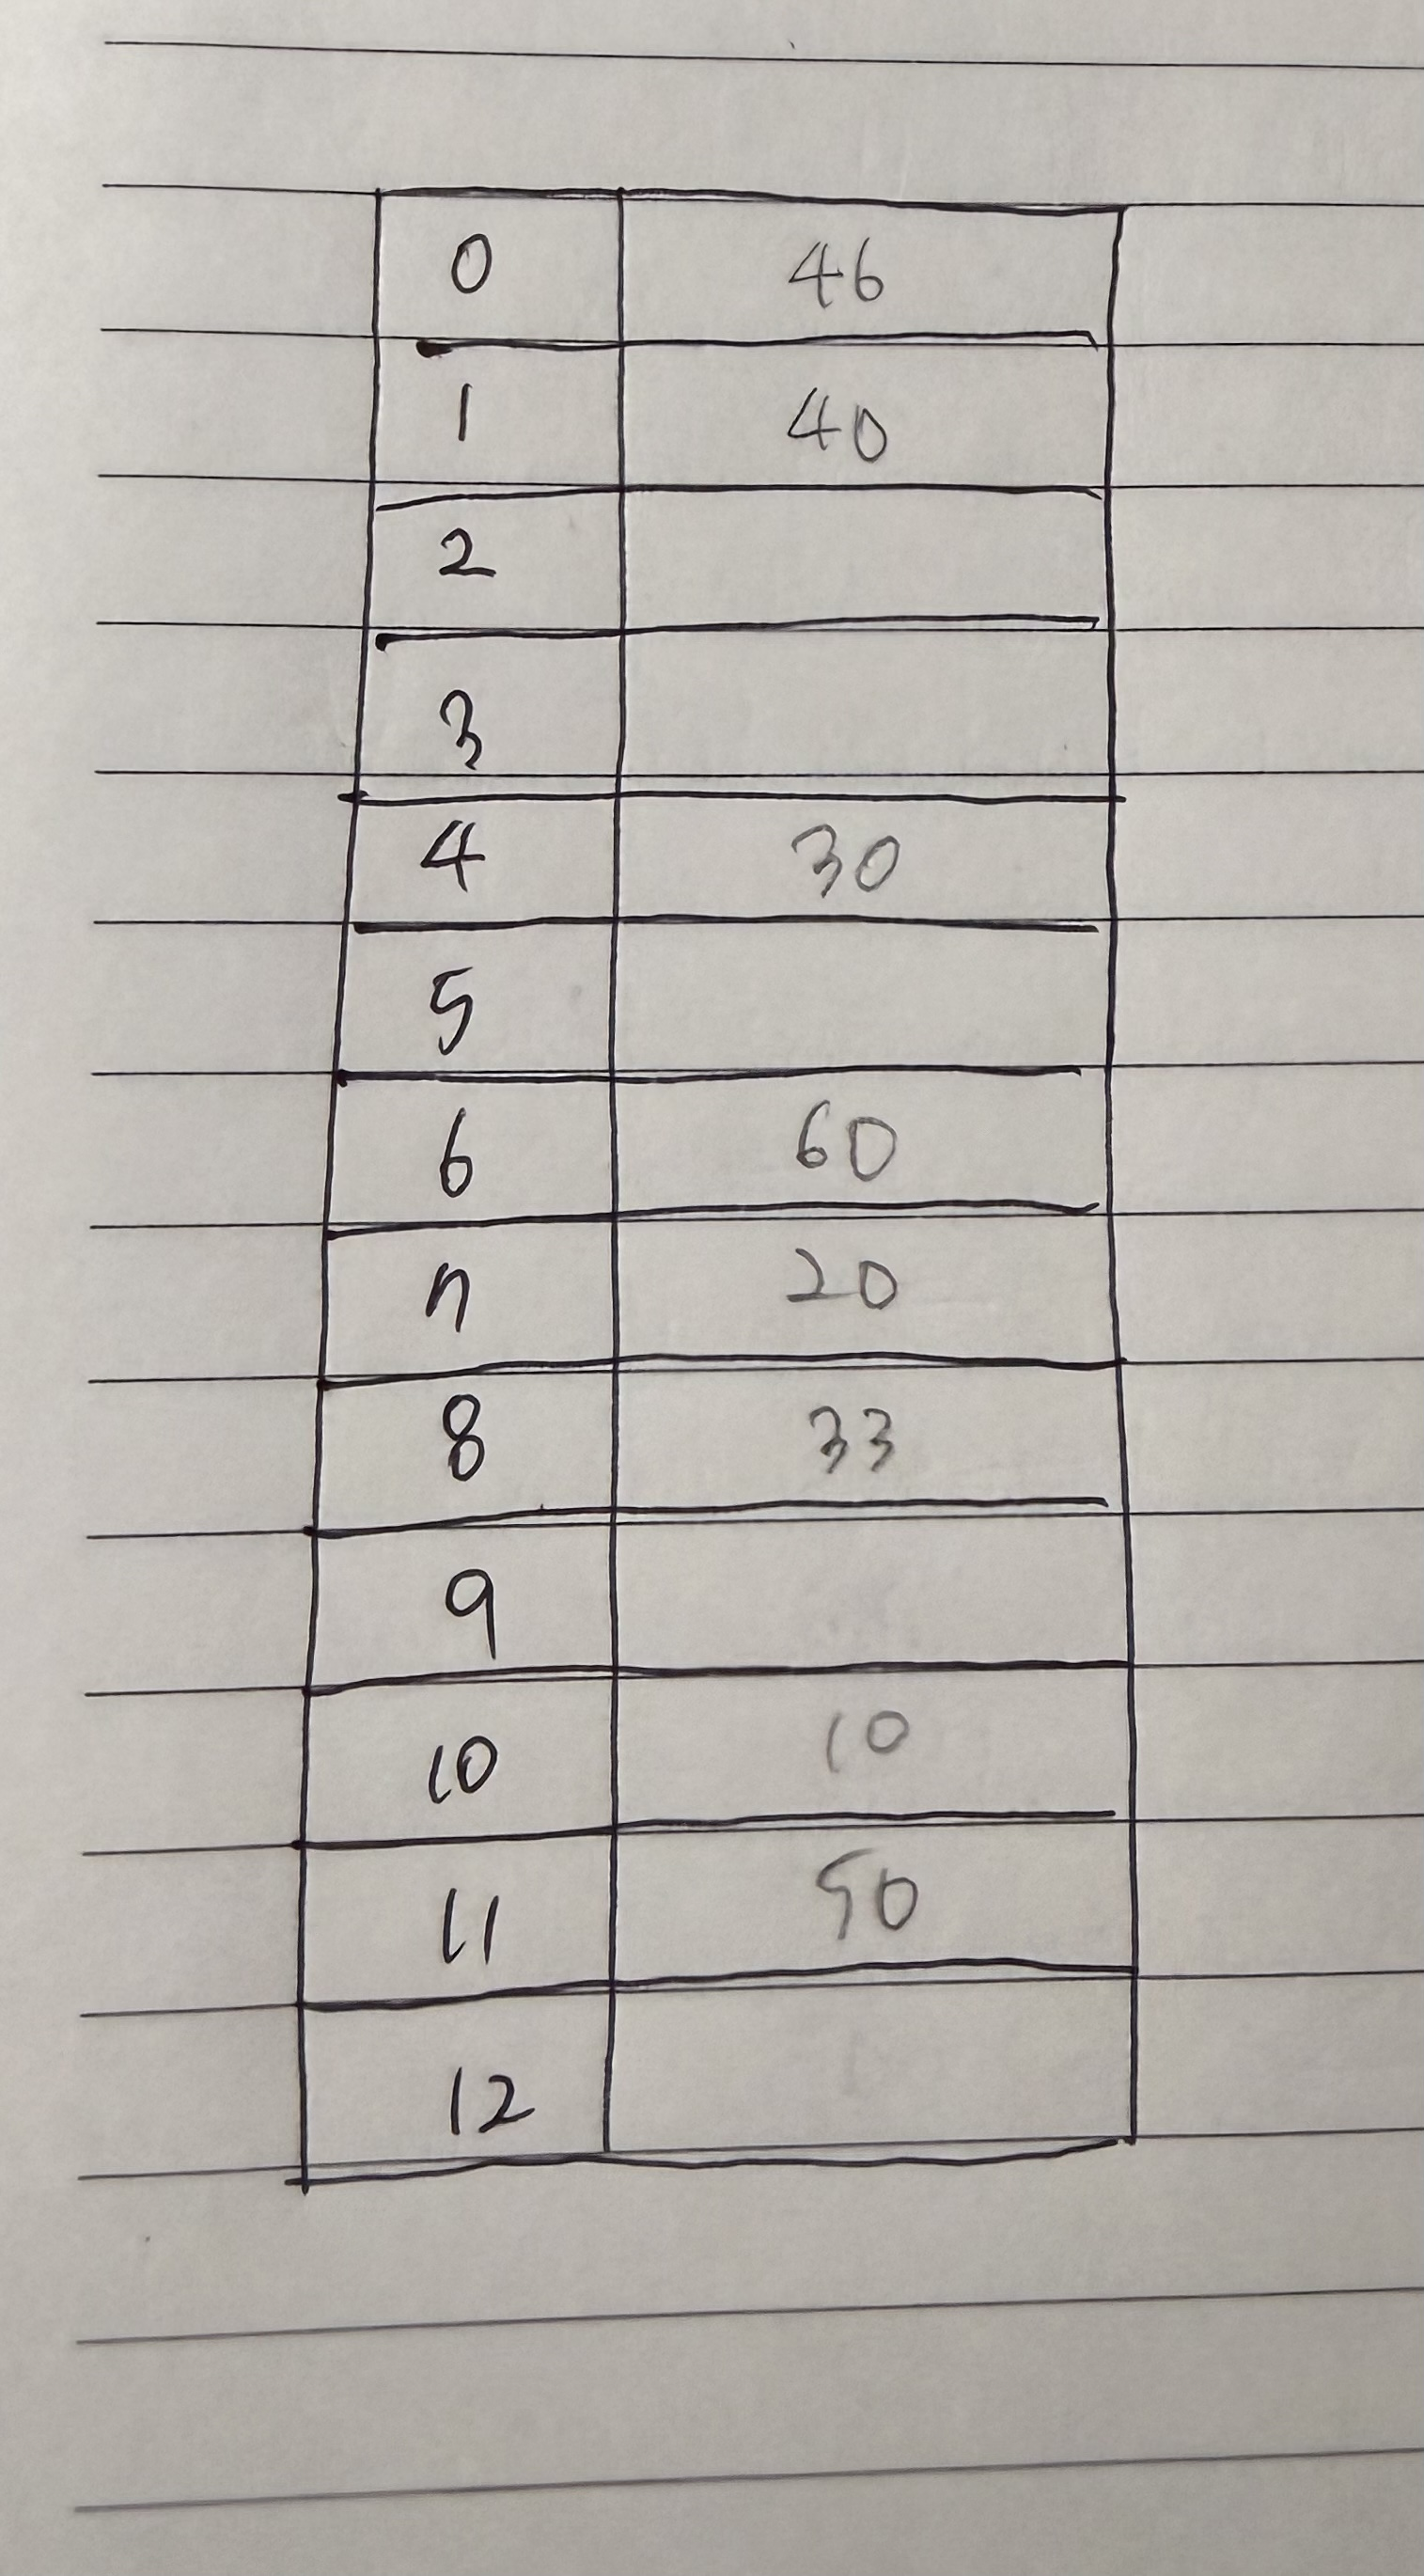60: $h(60)=8$ (충돌). $f(60) = 1+(60\%11) = 6$.$(8 + 1 \cdot 6) \pmod{13} = 1$ (충돌)$(8 + 2 \cdot 6) \pmod{13} = 7$ (충돌)$(8 + 3 \cdot 6) \pmod{13} = 26 \pmod{13} = 0$ (충돌)$(8 + 4 \cdot 6) \pmod{13} = 32 \pmod{13} = 6$ → [6] 저장

##2-07

일반적인 체이닝 기법에서는 새로운 노드를 리스트의 맨 앞에 삽입하여 $O(1)$의 시간 복잡도를 유지한다. 그러나 리스트의 맨 뒤에 삽입할 경우 다음과 같은 효율성 변화가 발생한다.

시간 복잡도 증가: 별도의 Tail 포인터를 유지하지 않는 경우, 리스트의 끝을 찾기 위해 전체 리스트를 순회해야 한다. 이로 인해 삽입 연산의 시간 복잡도가 $O(1)$에서 $O(L)$로 증가한다.

부가적인 오버헤드: 삽입 효율을 $O(1)$로 유지하려면 각 버킷마다 Tail 포인터를 추가로 관리해야 하므로, 메모리 사용량이 미세하게 증가하고 구현이 복잡해질 수 있다.

데이터 지역성: 보통 최근에 삽입된 데이터가 다시 참조될 가능성이 높은데, 맨 뒤에 삽입하면 이러한 최근성을 활용한 탐색 최적화 이점을 얻기 어렵다.

##2-08

연결 리스트를 정렬된 상태로 유지할 경우, 각 연산의 효율성은 다음과 같이 변화한다.

삽입 - 하락. 정렬 상태를 유지하기 위해 삽입 위치를 찾는 탐색 과정이 선행되어야 하므로 $O(1)$이 아닌 $O(L)$이 소요된다.

삭제 - 유지/미세 개선. 삭제할 대상을 찾기 위해 리스트를 순회해야 하므로 여전히 $O(L)$이다. 다만, 찾는 값보다 큰 값을 만나면 즉시 종료할 수 있어 평균적인 노드 방문 횟수는 줄어든다.

성공한 검색 - 유지. 찾고자 하는 데이터가 리스트에 존재하는 경우, 정렬 여부와 상관없이 해당 노드까지 도달해야 하므로 평균 $O(L/2)$의 비교가 발생한다.

실패한 검색 - 개선. 정렬되지 않은 리스트는 끝까지 가봐야 실패를 확신할 수 있지만($O(L)$), 정렬된 리스트는 탐색 키보다 큰 값을 만나는 순간 검색을 중단할 수 있다. 따라서 평균 비교 횟수가 약 절반으로 줄어든다.